# Capítulo 4: IA para la Detección de Malware

**Guía Técnica:** Inteligencia Artificial en Ciberseguridad  
**Mayo 2026**

---

## 4.1. Limitaciones del enfoque basado en firmas

Los sistemas antivirus tradicionales dependen de la detección basada en **firmas**, lo que los hace ineficaces frente a:

- **Malware nuevo** (*zero-day*): sin firma conocida, no se detecta.
- **Malware polimórfico**: cambia su código en cada infección.
- **Malware empaquetado**: cifra su payload para evadir el análisis estático.

La IA detecta malware analizando el **comportamiento** y las **características estructurales** de los archivos, sin depender de firmas.

### Contenido del capítulo
| Sección | Técnica |
|---|---|
| 4.2 | Extracción de características de archivos PE (`pefile`) |
| 4.3 | Construcción del dataset sintético |
| 4.4.1 | Clasificador — Árbol de Decisión |
| 4.4.2 | Clasificador — Random Forest + SMOTE |

---
## 4.2. Extracción de características de archivos PE

Los archivos ejecutables portátiles (PE) contienen metadatos ricos:
número de secciones, punto de entrada, tablas de importaciones/exportaciones, entropía, etc.

Las funciones siguientes se usarían sobre `.exe` reales. En este cuaderno las mostramos y luego generamos un dataset sintético que imita sus valores.

In [25]:
import math
import os
import pefile


def calcular_entropia(data: bytes) -> float:
    """Entropía de Shannon de un bloque de bytes."""
    if not data:
        return 0.0
    freq = [data.count(bytes([b])) / len(data) for b in range(256)]
    return -sum(p * math.log2(p) for p in freq if p > 0)


def extraer_caracteristicas_pe(ruta_archivo: str) -> dict:
    """
    Extrae características relevantes de un ejecutable PE.
    Retorna un dict con las características o None si falla.
    """
    try:
        pe = pefile.PE(ruta_archivo)
    except pefile.PEFormatError:
        print(f"[!] No es un PE válido: {ruta_archivo}")
        return None

    c = {}
    c["entry_point"]        = pe.OPTIONAL_HEADER.AddressOfEntryPoint
    c["image_base"]         = pe.OPTIONAL_HEADER.ImageBase
    # c["size_of_image"]      = pe.OPTIONAL_HEADER.SizeOfImage
    c["size_code_section"]  = pe.OPTIONAL_HEADER.SizeOfCode
    c["dll_flag"]           = pe.OPTIONAL_HEADER.DllCharacteristics

    entropias               = [calcular_entropia(s.get_data()) for s in pe.sections]
    c["num_sections"]       = len(pe.sections)
    c["entropia_max"]       = max(entropias)              if entropias else 0.0
    c["entropia_media"]     = sum(entropias)/len(entropias) if entropias else 0.0

    if hasattr(pe, "DIRECTORY_ENTRY_IMPORT"):
        c["num_importaciones"]  = sum(len(e.imports) for e in pe.DIRECTORY_ENTRY_IMPORT)
        c["num_dlls_importadas"] = len(pe.DIRECTORY_ENTRY_IMPORT)
    else:
        c["num_importaciones"]  = 0
        c["num_dlls_importadas"] = 0

    c["num_exportaciones"]  = len(pe.DIRECTORY_ENTRY_EXPORT.symbols) if hasattr(pe, "DIRECTORY_ENTRY_EXPORT") else 0
    c["file_size"]          = os.path.getsize(ruta_archivo)

    pe.close()
    return c


print("Funciones de extracción PE definidas correctamente.")
print("Para usarlas sobre un archivo real:")
print("  feats = extraer_caracteristicas_pe('ruta/archivo.exe')")

Funciones de extracción PE definidas correctamente.
Para usarlas sobre un archivo real:
  feats = extraer_caracteristicas_pe('ruta/archivo.exe')


---
## 4.3. Construcción del dataset sintético de malware

Generamos `file_features.csv` imitando los valores reales que `extraer_caracteristicas_pe` produciría:

| Característica | Benigno | Malicioso (empaquetado) |
|---|---|---|
| `entropia_max` | 4 – 6.5 | 7 – 8 (cifrado/comprimido) |
| `num_importaciones` | 50 – 250 | 2 – 30 (ocultas) |
| `num_sections` | 3 – 6 | 1 – 3 o > 8 |
| `file_size` | 50 KB – 5 MB | muy pequeño o muy grande |

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path("../data")
RNG      = np.random.default_rng(seed=42)

N_BENIGN    = 1500
N_MALICIOUS = 500   # desbalance intencional (25 %) — lo corregiremos con SMOTE

# --- Archivos benignos ---
benign = pd.DataFrame({
    "entry_point"        : RNG.integers(4096,  16384, N_BENIGN),
    "image_base"         : RNG.choice([0x400000, 0x1000000], N_BENIGN),
    "size_of_image"      : RNG.integers(50_000,  5_000_000, N_BENIGN),
    "size_code_section"  : RNG.integers(10_000,  2_000_000, N_BENIGN),
    "dll_flag"           : RNG.choice([256, 288, 320, 352], N_BENIGN),
    "num_sections"       : RNG.integers(3, 7, N_BENIGN),
    "entropia_max"       : RNG.uniform(4.0, 6.5, N_BENIGN),
    "entropia_media"     : RNG.uniform(3.5, 5.5, N_BENIGN),
    "num_importaciones"  : RNG.integers(50, 250, N_BENIGN),
    "num_dlls_importadas": RNG.integers(5,  20,  N_BENIGN),
    "num_exportaciones"  : RNG.integers(0,  5,   N_BENIGN),
    "file_size"          : RNG.integers(50_000, 5_000_000, N_BENIGN),
    "label"              : 0,
})

# --- Archivos maliciosos (empaquetados / cifrados) ---
malicious = pd.DataFrame({
    "entry_point"        : RNG.integers(1, 4096, N_MALICIOUS),           # entry point inusual
    "image_base"         : RNG.integers(0x10000, 0xFFFF0000, N_MALICIOUS),
    "size_of_image"      : RNG.integers(4096, 200_000, N_MALICIOUS),     # muy pequeño
    "size_code_section"  : RNG.integers(1000, 50_000,  N_MALICIOUS),
    "dll_flag"           : RNG.integers(0, 65535, N_MALICIOUS),          # flags aleatorios
    "num_sections"       : RNG.choice([1, 2, 9, 10, 11], N_MALICIOUS),  # pocas o muchas
    "entropia_max"       : RNG.uniform(7.2, 8.0, N_MALICIOUS),           # alta (cifrado)
    "entropia_media"     : RNG.uniform(6.8, 7.8, N_MALICIOUS),
    "num_importaciones"  : RNG.integers(2,  30,  N_MALICIOUS),           # muy pocas (ocultas)
    "num_dlls_importadas": RNG.integers(1,  5,   N_MALICIOUS),
    "num_exportaciones"  : RNG.integers(0,  2,   N_MALICIOUS),
    "file_size"          : RNG.integers(4096, 80_000, N_MALICIOUS),      # muy pequeño
    "label"              : 1,
})

df = pd.concat([benign, malicious], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

ruta = DATA_DIR / "file_features.csv"
df.to_csv(ruta, index=False)

print(f"Dataset guardado en : {ruta}")
print(f"Total de muestras   : {len(df):,}")
print(f"  Benigno           : {(df.label==0).sum():,}")
print(f"  Malicioso         : {(df.label==1).sum():,}")

Dataset guardado en : ..\data\file_features.csv
Total de muestras   : 2,000
  Benigno           : 1,500
  Malicioso         : 500


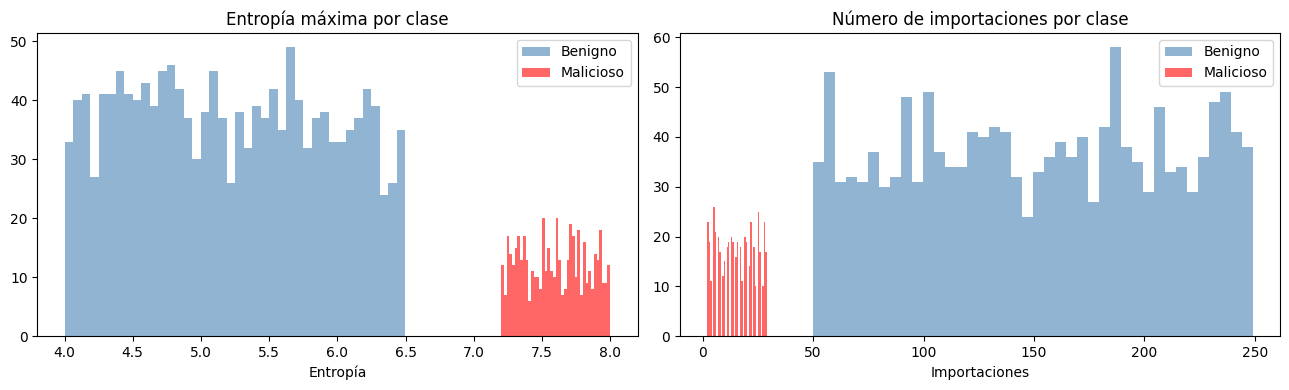

In [27]:
# Exploración visual: entropía y número de importaciones por clase
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color, nombre in [(0, "steelblue", "Benigno"), (1, "red", "Malicioso")]:
    subset = df[df.label == label]
    axes[0].hist(subset["entropia_max"],       bins=40, alpha=0.6, color=color, label=nombre)
    axes[1].hist(subset["num_importaciones"],  bins=40, alpha=0.6, color=color, label=nombre)

axes[0].set_title("Entropía máxima por clase")
axes[0].set_xlabel("Entropía")
axes[0].legend()

axes[1].set_title("Número de importaciones por clase")
axes[1].set_xlabel("Importaciones")
axes[1].legend()

plt.tight_layout()
plt.savefig(DATA_DIR / "malware_eda.png", dpi=150)
plt.show()

---
## 4.4. Modelo de clasificación de malware

### 4.4.1. Árbol de Decisión

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv(DATA_DIR / "file_features.csv").dropna()
X  = df.drop("label", axis=1)
y  = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = DecisionTreeClassifier(max_depth=10, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("=== Reporte de clasificación — Árbol de Decisión ===")
print(classification_report(y_test, y_pred, target_names=["Benigno", "Malicioso"]))

cv = cross_val_score(clf, X, y, cv=5, scoring="f1")
print(f"F1 CV (5-fold): {cv.mean():.4f} ± {cv.std():.4f}")

=== Reporte de clasificación — Árbol de Decisión ===
              precision    recall  f1-score   support

     Benigno       1.00      1.00      1.00       300
   Malicioso       1.00      1.00      1.00       100

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

F1 CV (5-fold): 1.0000 ± 0.0000


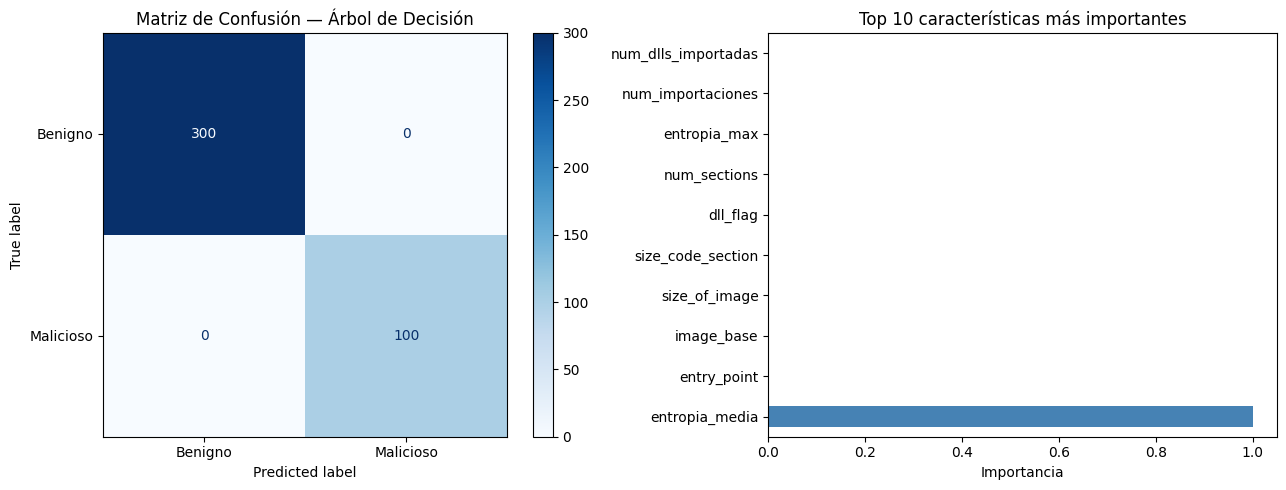

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Benigno", "Malicioso"]
).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Matriz de Confusión — Árbol de Decisión")

# Top 10 características más importantes
importancias = pd.Series(clf.feature_importances_, index=X.columns).nlargest(10)
importancias.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Top 10 características más importantes")
axes[1].set_xlabel("Importancia")

plt.tight_layout()
plt.savefig(DATA_DIR / "dt_resultados.png", dpi=150)
plt.show()

### 4.4.2. Random Forest con manejo de clases desbalanceadas (SMOTE)

**SMOTE** (*Synthetic Minority Oversampling Technique*) genera muestras sintéticas de la clase minoritaria (malicioso) para equilibrar el dataset antes de entrenar.

In [30]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Antes de SMOTE  : {y_train.value_counts().to_dict()}")
print(f"Después de SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")

Antes de SMOTE  : {0: 1200, 1: 400}
Después de SMOTE: {1: 1200, 0: 1200}


In [31]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)

print("=== Reporte de clasificación — Random Forest + SMOTE ===")
print(classification_report(y_test, y_pred_rf, target_names=["Benigno", "Malicioso"]))

=== Reporte de clasificación — Random Forest + SMOTE ===
              precision    recall  f1-score   support

     Benigno       1.00      1.00      1.00       300
   Malicioso       1.00      1.00      1.00       100

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



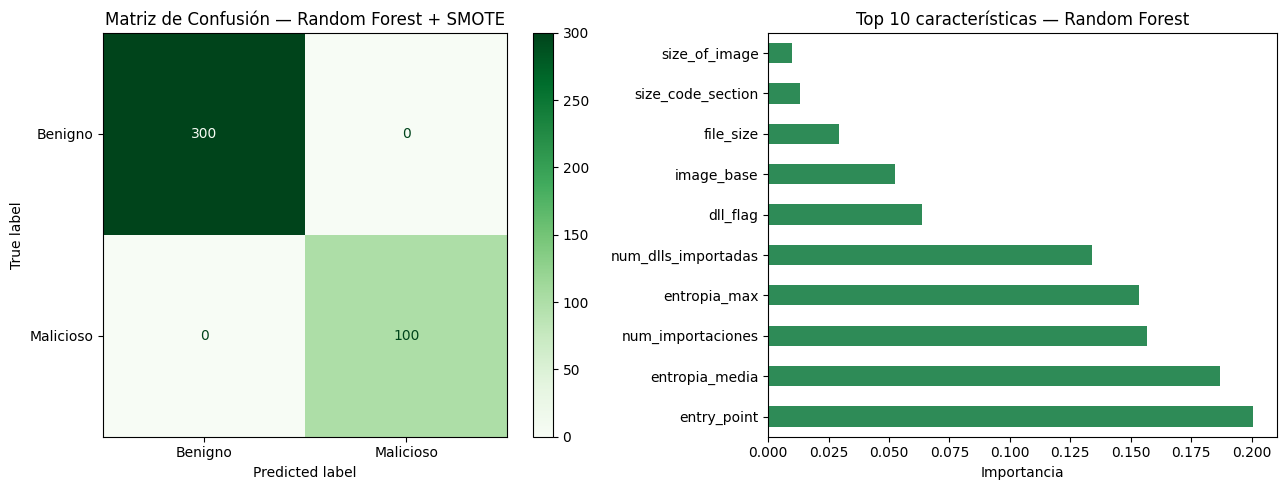

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión RF
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=["Benigno", "Malicioso"]
).plot(ax=axes[0], cmap="Greens")
axes[0].set_title("Matriz de Confusión — Random Forest + SMOTE")

# Importancia de características RF
imp_rf = pd.Series(rf.feature_importances_, index=X.columns).nlargest(10)
imp_rf.plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("Top 10 características — Random Forest")
axes[1].set_xlabel("Importancia")

plt.tight_layout()
plt.savefig(DATA_DIR / "rf_resultados.png", dpi=150)
plt.show()

---
## Comparación de modelos

| Modelo | Ventaja | Desventaja |
|---|---|---|
| **Árbol de Decisión** | Interpretable, rápido | Propenso a overfitting |
| **Random Forest + SMOTE** | Robusto, maneja desbalance | Menos interpretable, más lento |

---
**Siguiente:** Capítulo 5 → IA para la Automatización de la Respuesta a Incidentes